# Retrieval Augmented Generation (RAG)

Essentially the steps in RAG are as follows:

1. Collect documents that will be used for RAG, these are usually stored in a folder.
2. Break the documents into smaller chunks, often with overlapping chunks.
3. Create embeddings for each chunk and put them in a vector store.
4. When a query is issued, use a retriever to pull up the relevant chunks and return them in a JSON structure.
5. Use a LLM to work on the chunks to answer the query in natural language.

This means that two models are needed:
1. An embedding model.
2. A LLM to construct the response.

In [1]:
from google.colab import drive
drive.mount('/content/drive')  # Add My Drive/<>

import os
os.chdir('drive/My Drive')
os.chdir('Books_Writings/NLPBook/')

Mounted at /content/drive


In [2]:
%%capture
%pylab inline
import pandas as pd
import os
from IPython.display import Image

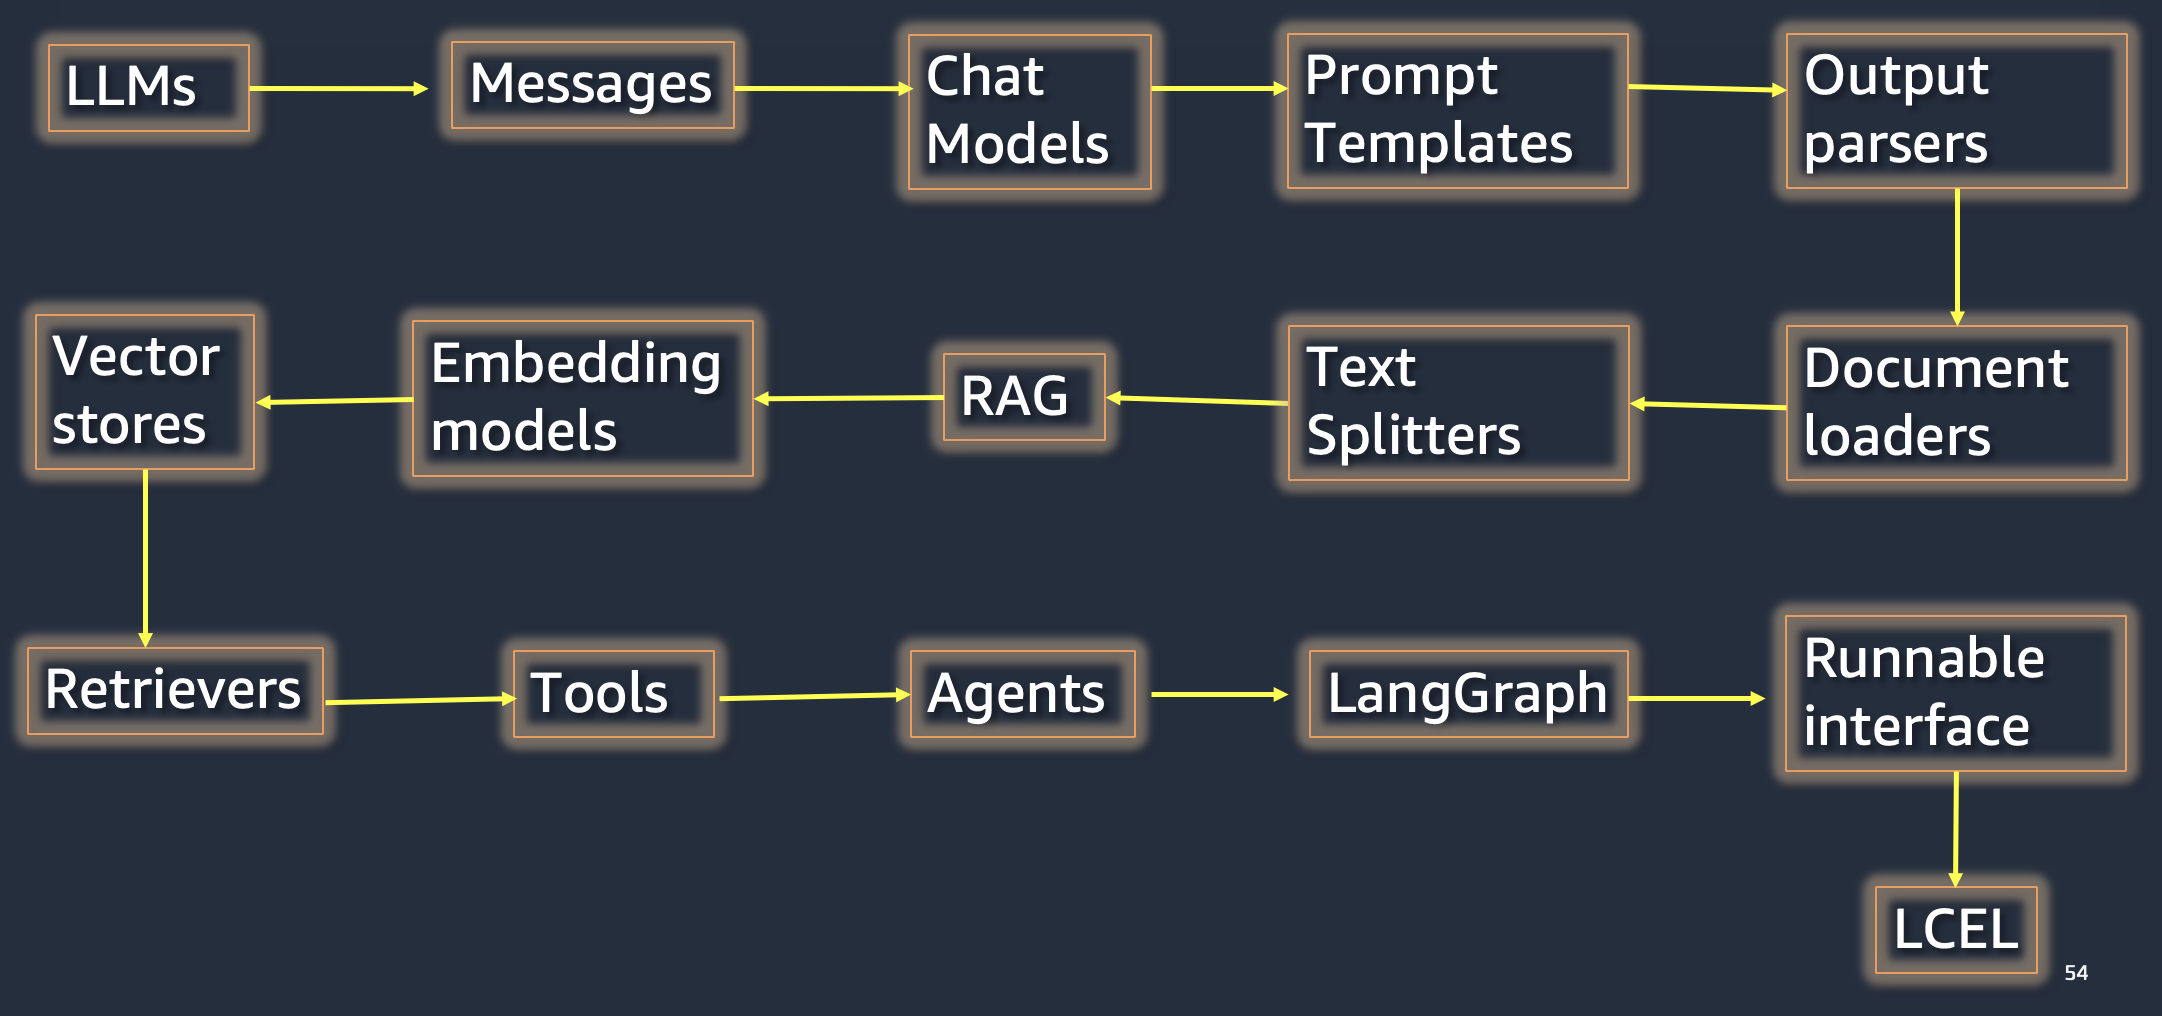

In [ ]:
Image('NLP_images/langchain_components.png', width=800)

In [3]:
!pip install --quiet openai
# !pip install chromadb
# !pip install tiktoken
# !pip install faiss

## Load in API Keys

Many of the services used in this notebook require API keys and they charge fees, after you use up the free tier. We store the keys in a separate notebook so as to not reveal them here. Then by running that notebook all the keys are added to the environment.

Set up your own notebook with the API keys and it should look as follows:

```
import os

OPENAI_KEY = '<Your API Key here>'
os.environ['OPENAI_API_KEY'] = OPENAI_KEY

HF_API_KEY = '<Your API Key here>'
os.environ['HUGGINGFACEHUB_API_TOKEN'] = HF_API_KEY

SERPAPI_KEY = '<Your API Key here>'
os.environ['SERPAPI_API_KEY'] = SERPAPI_KEY

WOLFRAM_ALPHA_KEY = '<Your API Key here>'
os.environ['WOLFRAM_ALPHA_APPID'] = WOLFRAM_ALPHA_KEY

GOOGLE_KEY = '<Your API Key here>'

keys = ['OPENAI_KEY', 'HF_API_KEY', 'SERPAPI_KEY', 'WOLFRAM_ALPHA_KEY']
print("Keys available: ", keys)
```



In [4]:
%run keys.ipynb

In [5]:
import numpy as np
import os
import textwrap
import openai

def p80(text):
    print(textwrap.fill(text, 80))
    return None

## RAG Code

In [6]:
from typing import List, Tuple
import os
import openai
import numpy as np
from dotenv import load_dotenv

# Set the API type to OpenAI
openai.api_type = "openai"

# Embeddings manager to create embeddings for texts
class EmbeddingsManager:
    def __init__(self, api_key: str):
        openai.api_key = api_key

    def create_embeddings(self, texts: List[str]) -> List[np.ndarray]:
        embeddings = []
        for text in texts:
            response = openai.embeddings.create(
                model="text-embedding-ada-002",
                input=text
            )
            embeddings.append(np.array(response.data[0].embedding))
        return embeddings

# Simple retrieval system using cosine similarity of embeddings
class RetrievalSystem:
    def __init__(self, chunks: List[str], embeddings: List[np.ndarray]):
        self.chunks = chunks
        self.embeddings = embeddings

    def find_similar_chunks(self, query_embedding: np.ndarray, top_k: int = 3) -> List[Tuple[str, float]]:
        similarities = []
        for i, emb in enumerate(self.embeddings):
            similarity = np.dot(query_embedding, emb) / (np.linalg.norm(query_embedding) * np.linalg.norm(emb))
            similarities.append((self.chunks[i], similarity))
        # Sort by similarity descending and return top_k
        return sorted(similarities, key=lambda x: x[1], reverse=True)[:top_k]

# RAG system putting it all together
class RAGSystem:
    def __init__(self, documents: List[str]):
        load_dotenv()
        self.api_key = os.getenv("OPENAI_API_KEY")
        self.emb_manager = EmbeddingsManager(self.api_key)

        # Simple text chunking (e.g., by paragraphs)
        self.chunks = []
        for doc in documents:
            self.chunks.extend(doc.split("\n\n"))  # Naive paragraph chunking

        # Create embeddings for all chunks
        self.embeddings = self.emb_manager.create_embeddings(self.chunks)

        # Initialize retrieval
        self.retrieval_system = RetrievalSystem(self.chunks, self.embeddings)

    def answer_question(self, question: str) -> str:
        # Create embedding for question
        query_embedding = self.emb_manager.create_embeddings([question])[0]

        # Retrieve relevant chunks
        relevant = self.retrieval_system.find_similar_chunks(query_embedding)

        # Prepare context string from top chunks
        context = "\n".join([chunk for chunk, _ in relevant])

        # Compose prompt with context and question
        prompt = f"Context: {context}\n\nQuestion: {question}\n\nAnswer:"

        # Call OpenAI chat completion with context-aware prompt
        response = openai.chat.completions.create(
            model="gpt-4.1",
            messages=[
                {"role": "system", "content": "You are a helpful assistant. Use the context to answer the question."},
                {"role": "user", "content": prompt}
            ]
        )
        return response.choices[0].message.content


# Example usage:

if __name__ == "__main__":
    # Provide documents to be used in retrieval
    documents = [
        "Kai faced the guardian's riddle and after long thought found the answer.\n\nThis enabled Kai to proceed with the quest.",
        "The riddle was tricky but understanding the clues was key to success."
    ]

    rag = RAGSystem(documents)

    question = "What was the answer to the guardian’s riddle, and how did it help Kai?"
    answer = rag.answer_question(question)
    print("Answer:", answer)

Answer: The answer to the guardian's riddle was the crucial piece of information Kai needed to advance in the quest. By carefully analyzing and understanding the clues within the riddle, Kai was able to identify the correct answer. This impressed the guardian and allowed Kai to pass through the obstacle or gain access to the next stage of the journey, thus enabling continued progress in the quest. The answer demonstrated Kai’s cleverness and problem-solving skills, which were essential for succeeding in the adventure.


In [7]:
p80(answer)

The answer to the guardian's riddle was the crucial piece of information Kai
needed to advance in the quest. By carefully analyzing and understanding the
clues within the riddle, Kai was able to identify the correct answer. This
impressed the guardian and allowed Kai to pass through the obstacle or gain
access to the next stage of the journey, thus enabling continued progress in the
quest. The answer demonstrated Kai’s cleverness and problem-solving skills,
which were essential for succeeding in the adventure.


## Do RAG: Enhance Context with Text Files

- We now include additional information to bolster the context provided to the LLM in framing a response. This is also known as Retrieval Augmented Generation (RAG). Paper: [Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks 2020](https://arxiv.org/abs/2005.11401).

- A collection of documents is sharded, converted into embeddings and then dropped into a vector store (vector database). These are then retrieved based on similarity/relevance to the query and used as context in formulating a response.

- The vector store is created using ChromaDB, it uses DuckDB and Apache Parquet, and by default, it uses an in-memory database.

- For an interesting use case, see: https://blog.devgenius.io/how-to-ensure-openais-gpt-3-provides-an-accurate-answer-and-stays-on-topic-af5da300ba81

In [8]:
!pip install langchain_community --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.2/471.2 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
langchain 0.3.27 requires langchain-core<1.0.0,>=0.3.72, but you have langchain-core 1.0.4 which is incompatible.
langchain 0.3.27 requires langchain-text-splitters<1.0.0,>=0.3.9, but you have langchain-text-splitters 1.0.0 which is incompatible.


In [9]:
import os
from langchain_community.document_loaders import DirectoryLoader, TextLoader

# Directory containing the text files
directory_path = 'DOCS_GAI/'

# Use DirectoryLoader with TextLoader to load documents
loader = DirectoryLoader(directory_path, glob="*.txt", loader_cls=TextLoader)
documents = loader.load()

print("Number of docs =", len(documents))

Number of docs = 5


In [10]:
# Shard all the documents
from langchain.text_splitter import CharacterTextSplitter
text_splitter = CharacterTextSplitter(chunk_size=5000, chunk_overlap=0)
texts = text_splitter.split_documents(documents)
print("Number of shards =", len(texts))
print(type(texts))
print(type(texts[0]))

Number of shards = 55
<class 'list'>
<class 'langchain_core.documents.base.Document'>


In [11]:
texts[3]

Document(metadata={'source': 'DOCS_GAI/mdna_googl.txt'}, page_content="•Other Bets is a combination of multiple operating segments that are not\nindividually material. Revenues from the Other Bets are derived primarily\nthrough the sale of internet services as well as licensing and R&D services.\n\nUnallocated corporate costs primarily include corporate initiatives, corporate\nshared costs, such as finance and legal, including fines and settlements, as\nwell as costs associated with certain shared research and development\nactivities. Additionally, hedging gains (losses) related to revenue are\nincluded in corporate costs.\n\nFinancial Results\n\nRevenues\n\nThe following table presents our revenues by type (in millions).\n\nGoogle Services\n\nGoogle advertising revenues\n\nOur advertising revenue growth, as well as the change in paid clicks and cost-\nper-click on Google Search & other properties and the change in impressions\nand cost-per-impression on Google Network Members' propert

In [12]:
from typing import List, Tuple
import os
import openai
import numpy as np
from dotenv import load_dotenv
from langchain_core.documents import Document

# Set the API type to OpenAI
openai.api_type = "openai"

# Embeddings manager to create embeddings for texts
class EmbeddingsManager:
    def __init__(self, api_key: str):
        openai.api_key = api_key

    def create_embeddings(self, texts: List[str]) -> List[np.ndarray]:
        embeddings = []
        for text in texts:
            response = openai.embeddings.create(
                model="text-embedding-ada-002",
                input=text
            )
            embeddings.append(np.array(response.data[0].embedding))
        return embeddings

# Simple retrieval system using cosine similarity of embeddings
class RetrievalSystem:
    def __init__(self, chunks: List[Document], embeddings: List[np.ndarray]):
        self.chunks = chunks
        self.embeddings = embeddings

    def find_similar_chunks(self, query_embedding: np.ndarray, top_k: int = 3) -> List[Tuple[Document, float]]:
        similarities = []
        for i, emb in enumerate(self.embeddings):
            similarity = np.dot(query_embedding, emb) / (np.linalg.norm(query_embedding) * np.linalg.norm(emb))
            similarities.append((self.chunks[i], similarity))
        # Sort by similarity descending and return top_k
        return sorted(similarities, key=lambda x: x[1], reverse=True)[:top_k]

# RAG system putting it all together
class RAGSystem:
    def __init__(self, documents: List[Document]):
        load_dotenv()
        self.api_key = os.getenv("OPENAI_API_KEY")
        self.emb_manager = EmbeddingsManager(self.api_key)

        # Simple text chunking (e.g., by paragraphs)
        # self.chunks = []
        # for doc in documents:
        #     self.chunks.extend(doc.split("\n\n"))  # Naive paragraph chunking
        self.chunks = text_splitter.split_documents(documents)

        # Create embeddings for all chunks
        # self.embeddings = self.emb_manager.create_embeddings(self.chunks)
        # Extract the text content from the Document objects
        chunk_texts = [chunk.page_content for chunk in self.chunks]
        self.embeddings = self.emb_manager.create_embeddings(chunk_texts)


        # Initialize retrieval
        self.retrieval_system = RetrievalSystem(self.chunks, self.embeddings)

        # Store original documents for later retrieval
        self.original_documents = documents

    def answer_question(self, question: str) -> str:
        # Create embedding for question
        query_embedding = self.emb_manager.create_embeddings([question])[0]

        # Retrieve relevant chunks
        relevant = self.retrieval_system.find_similar_chunks(query_embedding)

        # Prepare context string from top chunks
        context = "\n".join([chunk.page_content for chunk, _ in relevant])

        # Compose prompt with context and question
        prompt = f"Context: {context}\n\nQuestion: {question}\n\nAnswer:"

        # Call OpenAI chat completion with context-aware prompt
        response = openai.chat.completions.create(
            model="gpt-4-turbo-preview",
            messages=[
                {"role": "system", "content": "You are a helpful assistant. Use the context to answer the question."},
                {"role": "user", "content": prompt}
            ]
        )
        return response.choices[0].message.content

    def get_source_documents(self, query: str) -> List[Document]:
        """
        Returns the original source documents relevant to the query.
        """
        # Create embedding for the query
        query_embedding = self.emb_manager.create_embeddings([query])[0]

        # Retrieve relevant chunks
        relevant_chunks = self.retrieval_system.find_similar_chunks(query_embedding)

        # Get the source document paths from the relevant chunks
        source_paths = set()
        for chunk, _ in relevant_chunks:
            if 'source' in chunk.metadata:
                source_paths.add(chunk.metadata['source'])

        # Find the original documents that match the source paths
        relevant_documents = [
            doc.metadata.get('source') for doc in self.original_documents if doc.metadata.get('source') in source_paths
        ]

        return relevant_documents

In [13]:
# Provide documents to be used in retrieval
rag = RAGSystem(documents)

## Examples

Now issue a query. `langchain` will look up the vector store to get the relevant text as context and then pass it to the LLM to construct the final response.

In [14]:
query = "What is the forward-looking business outlook for Amazon?"
p80(rag.answer_question(query))

The forward-looking business outlook for Amazon, as depicted in the context
provided, suggests a focus on achieving long-term, sustainable growth in free
cash flows. This growth is anticipated to come from increasing operating income
and efficiently managing various financial aspects such as accounts receivable,
inventory, accounts payable, and cash capital expenditures. Amazon intends to
drive increases in operating income through higher sales of products and
services while managing operating costs effectively. Part of this strategy
includes making investments in strategic initiatives and capital expenditures
aimed at enhancing the customer experience.  The company plans to continue
increasing unit sales across its platforms by expanding product selection,
improving the customer experience through lower prices, better availability,
faster delivery, increased selection, original content production, expansion of
product categories and service offerings, and enhancing product information

In [15]:
query = "What is the expectation of net sales for the first quarter of 2021 for Amazon?"
p80(rag.answer_question(query))

The expectation for Amazon's net sales for the first quarter of 2021 is to be
between $100.0 billion and $106.0 billion, representing a growth of between 33%
and 40% compared with the first quarter of 2020. This guidance also anticipates
a favorable impact of approximately 300 basis points from foreign exchange
rates.


In [16]:
query = "Compare the sales of Amazon versus Miscrosoft"
p80(rag.answer_question(query))

To effectively compare the sales of Amazon versus Microsoft, it's essential to
understand each company's context and how their revenue streams differ. Based on
the information provided:  **Amazon Sales Overview:** - Amazon's net sales
include products and services such as third-party seller fees, Amazon Web
Services (AWS), advertising services, and Amazon Prime membership fees. These
sales saw significant increases in 2020:   - Sales increased by 38% in 2020 over
the previous year.   - North America sales were up by 38% in 2020.   -
International sales increased by 40% in 2020.   - AWS sales grew by 30% in 2020.
**Microsoft Sales Overview:** - Microsoft generates revenue through a variety of
channels including cloud-based services, the licensing of software products,
devices sales, and online advertising. Highlights from their fiscal year 2021:
- Office Commercial products and cloud services revenue increased by 13%, driven
by Office 365 Commercial growth of 22%.   - LinkedIn revenue i

In [17]:
query = "Compare the profitability of Amazon versus Miscrosoft"
p80(rag.answer_question(query))

To compare the profitability of Amazon versus Microsoft, it is essential to look
at several key financial performance metrics from each company's management
discussion and analysis. However, the provided text mainly covers details from
Microsoft's annual report, highlighting its financial performance and strategic
focus areas without presenting similar detailed information for Amazon.  Based
on Microsoft's excerpt:  1. **Revenue Growth:** Microsoft experienced
significant revenue growth from various segments. For instance, its Office
Commercial and cloud services revenue grew by 13%, and its Dynamics products and
cloud services revenue increased by 25%. Server products and cloud services
revenue increased by 27%, partly due to Azure's growth of 50%. This indicates
strong overall revenue growth, particularly boosted by its cloud services.  2.
**Profitability:** Microsoft's operating income increased in its Intelligent
Cloud and More Personal Computing segments, suggesting improved profi

The code below shows how to pull up the referenced documents from the vector database.

In [18]:
relevant_docs = rag.get_source_documents(query)
print(relevant_docs)

['DOCS_GAI/mdna_msft.txt', 'DOCS_GAI/mdna_amzn.txt']


In [19]:
# Print the first 100 lines only
doc = relevant_docs[0]

j = 0
with open(doc, "r") as f:
  for line in f:
    j = j + 1
    print(line, end="")
    if j>100:
      break

"ITEM 7. MANAGEMENT’S DISCUSSION AND ANALYSIS OF FINANCIAL CONDITION AND
RESULTS OF OPERATIONS

The following Management’s Discussion and Analysis of Financial Condition and
Results of Operations (“MD&A”) is intended to help the reader understand the
results of operations and financial condition of Microsoft Corporation. MD&A
is provided as a supplement to, and should be read in conjunction with, our
consolidated financial statements and the accompanying Notes to Financial
Statements (Part II, Item 8 of this Form 10-K). This section generally
discusses the results of our operations for the year ended June 30, 2021
compared to the year ended June 30, 2020. For a discussion of the year ended
June 30, 2020 compared to the year ended June 30, 2019, please refer to Part
II, Item 7, “Management’s Discussion and Analysis of Financial Condition and
Results of Operations” in our Annual Report on Form 10-K for the year ended
June 30, 2020.

OVERVIEW

Microsoft is a technology company whose missi

## Future of RAG

1. As the context window for LLMs has grown (Gemini has a 10 million token window and many LLMs are in the 128K range), RAG may be less needed, especially if the number of documents to be added as reference is small. Of course, with a large library of documents, RAG will still be required.

2. The references below discuss the 4Vs of big data as challenges to RAG performance:
  - Velocity (inference response times),
  - Value and cost (pricing per token has become cheaper but there is still a large number of tokens, only increasing with time),
  - Volume (search indexes swamp any context window size), and
  - Variety (search indexes are far more diverse than vector stores).

3. Improvements in Embedding algorithms will help. Large context needs to be chunked and then embedded and there is no easy way to optimize this, for both the embedding (input) and retrieval (output from the vector store). Chunking free architectures such as BGE Landmark Embedding (replacing chunk embeddings with landmark embeddings) offer promise on cost, accuracy, and latency. For details, see: https://arxiv.org/abs/2402.11573

4. A separate direction in which RAG goes is designing better vector database technology.



## What is Graph RAG?

Graph RAG, or Graph Retrieval-Augmented Generation, is an advanced approach in natural language processing (NLP) that combines the strengths of graph-based knowledge retrieval with large language models (LLMs). Unlike standard RAG, which stores data in unstructured text, Graph RAG creates a knowledge graph based on the queried dataset and uses graph machine learning to improve the model's ability to answer nuanced and complex queries.

In Graph RAG, the external knowledge base is represented as a knowledge graph, where nodes represent entities and edges represent the relationships between them. This structured representation allows the RAG system to traverse the graph and retrieve relevant subgraphs based on the user's query. The retrieved subgraphs provide the LLM with a focused, context-rich subset of the knowledge graph, enabling it to generate more accurate and informative responses.

Graph RAG converts unstructured text into a structured form (the knowledge graph) and aims to reduce hallucinations. If the use case demands a deep understanding of complex relationships, benefits from domain-specific knowledge, and requires a high level of explainability, Graph RAG is likely the better choice.

References:

1. https://ragaboutit.com/graph-rag-vs-vector-rag-a-comprehensive-tutorial-with-code-examples/
2. https://www.reddit.com/r/ArtificialInteligence/comments/1e4rsr6/graph_rag_codes_explained/
3. https://www.ontotext.com/knowledgehub/fundamentals/what-is-graph-rag/
4. https://www.capestart.com/resources/blog/what-is-graphrag-is-it-better-than-rag/
5. https://www.reddit.com/r/learnmachinelearning/comments/1dy5nk6/what_is_graphrag_explained/
6. https://www.linkedin.com/pulse/how-does-microsofts-graphrag-fit-graph-rag-ecosystem-atanas-kiryakov-kg0jf

## Reviews and References

1. An excellent overview of LLMs (August 3, 2023): https://simonwillison.net/2023/Aug/3/weird-world-of-llms/

2. Will Retrieval Augmented Generation (RAG) Be Killed by Long-Context LLMs? (August 30, 2024): https://thesequence.substack.com/p/guest-post-will-retrieval-augmented
